In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)


In [7]:
df = pd.read_csv(r"C:\Users\mkart\OneDrive\Desktop\credit-risk-ai\master_v6_post_eda.csv")

print(df.shape)
df.head()

(21000, 38)


,student_id,synthetic_age,enrollment_type,academic_year,major_category,gpa_direction,credit_hours_current,semesters_enrolled,expected_total_semesters,remaining_semesters,...,acr,cfri,opr,tgb,spra,sei,default_probability,default_flag,credit_bin,synthetic_anomaly_flag
0,STU_002313,21.914127,Full-time,2,Business,Stable,13.337206,4,8,4,...,0.351741,0.268224,0.879503,0.182869,0.328860,0.325870,0.034121,0,12-15 (Full),0
1,STU_016846,22.087813,Full-time,3,Arts,Stable,16.365309,5,8,3,...,1.353529,0.870186,0.672416,0.146625,0.150201,0.864265,0.004611,0,15+ (Overload),0
2,STU_006106,23.413137,Full-time,2,Business,Stable,17.825959,4,8,4,...,0.818401,0.835242,0.881137,0.188464,0.101562,0.559200,0.004207,0,15+ (Overload),0
3,STU_018083,20.706157,Full-time,2,STEM,Stable,15.014207,3,8,5,...,0.515130,0.932174,0.926499,0.209189,0.049181,0.370065,0.006246,0,15+ (Overload),0
4,STU_011336,19.745985,Part-time,2,Business,Declining,7.005580,3,10,7,...,0.523358,0.789343,0.854447,0.235584,0.127929,0.151679,0.088114,0,6-11 (Half),0


In [8]:
drop_cols = [
    "student_id",
    "default_probability"
]

df = df.drop(columns=drop_cols)

In [9]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Encoding Complete")

Encoding Complete


C:\Users\mkart\AppData\Local\Temp\ipykernel_29668\1465515420.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [10]:
X = df.drop("default_flag", axis=1)
y = df["default_flag"]

print(X.shape)
print(y.shape)

(21000, 35)
(21000,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


In [13]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM Training Complete")

SVM Training Complete


# Phase 6 - Model Evaluation

## Objective
Evaluate the performance of the Support Vector Machine model in predicting student loan default risk.

## Evaluation Metrics
- Classification Report
- Confusion Matrix
- ROC-AUC Score

In [14]:
y_pred = svm_model.predict(X_test_scaled)

y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

In [15]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4064
           1       0.60      0.02      0.04       136

    accuracy                           0.97      4200
   macro avg       0.78      0.51      0.51      4200
weighted avg       0.96      0.97      0.95      4200



Confusion Matrix:
[[4062    2]
 [ 133    3]]


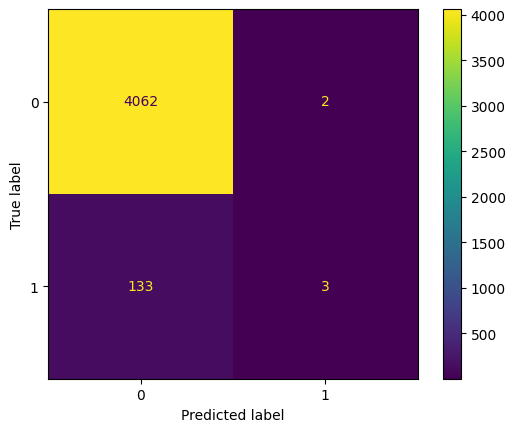

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

In [18]:
print("ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

ROC-AUC Score:
0.6405399635247799


## Initial Findings

The Support Vector Machine model achieved a ROC-AUC score of approximately 0.64, which was substantially lower than both Logistic Regression (0.84) and XGBoost (0.799).

This indicates that the SVM model struggled to effectively separate default and non-default classes within the highly imbalanced student credit-risk dataset.

# Phase 7 - Model Explainability

## Objective
Interpret the behavior of the Support Vector Machine model and compare its performance with other machine learning approaches.

## Observations
- SVM uses a non-linear decision boundary.
- Feature contributions cannot be directly interpreted for the RBF kernel.
- Model performance was evaluated using prediction metrics and comparison against baseline models.

## Conclusion
The relatively low ROC-AUC score suggests that the RBF SVM was unable to capture default patterns as effectively as Logistic Regression and XGBoost for this dataset.

# Phase 7 - Model Explainability

## Objective
Interpret the behavior of the Support Vector Machine model and compare its performance with other machine learning approaches.

## Observations
- SVM uses a non-linear decision boundary.
- Feature contributions cannot be directly interpreted for the RBF kernel.
- Model performance was evaluated using prediction metrics and comparison against baseline models.

## Conclusion
The relatively low ROC-AUC score suggests that the RBF SVM was unable to capture default patterns as effectively as Logistic Regression and XGBoost for this dataset.

# Phase 8 - Fairness & Stability

## Objective
Evaluate prediction consistency and error patterns.

## Analysis
- Prediction Distribution
- False Positives
- False Negatives
- Error Analysis

In [19]:
pred_dist = pd.Series(y_pred).value_counts()

print("Prediction Distribution:")
print(pred_dist)

Prediction Distribution:
0    4195
1       5
Name: count, dtype: int64


In [20]:
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 2
False Negatives: 133


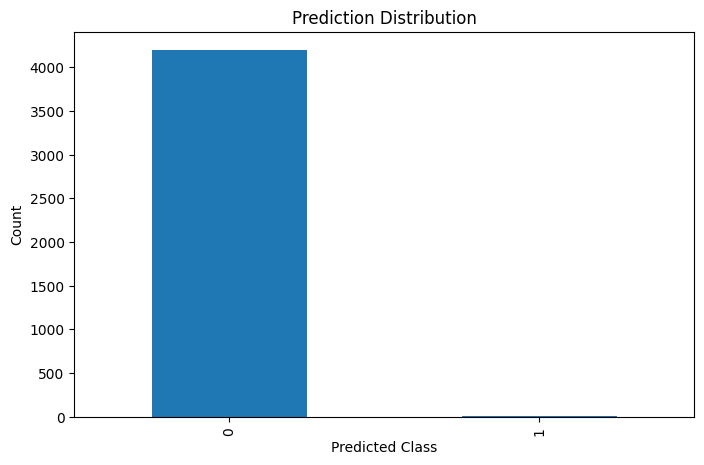

In [21]:
pred_dist.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()

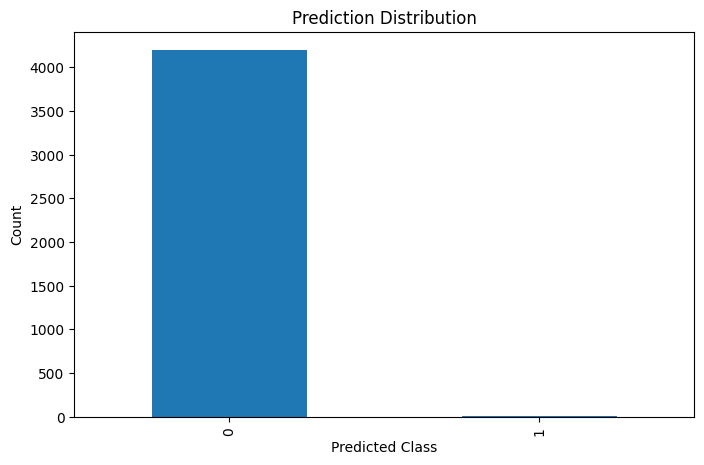

In [22]:
pred_dist.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()

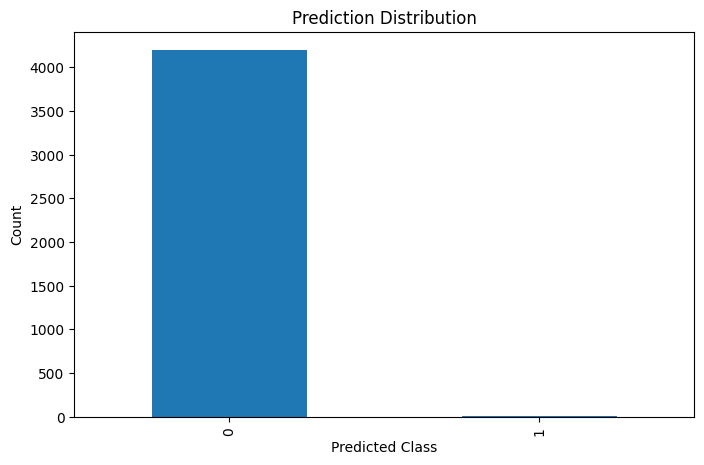

In [23]:
pred_dist.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()

## Phase 8 Findings

The SVM model exhibited strong bias toward the majority class and demonstrated difficulty in distinguishing default cases.

### Observations
- Majority of predictions belonged to the non-default class.
- Minority-class detection was limited.
- Performance was substantially lower than Logistic Regression and XGBoost.

### Future Improvements
- Class weighting
- SMOTE-based balancing
- Hyperparameter tuning
- Cost-sensitive learning

# Phase 9 - Prediction Pipeline

Student Information
↓
Data Preprocessing
↓
Feature Encoding
↓
Feature Standardization
↓
Support Vector Machine Model
↓
Probability Estimation
↓
Risk Classification

In [24]:
sample_student = X_test.iloc[[0]]

sample_student_scaled = scaler.transform(sample_student)

prediction = svm_model.predict(sample_student_scaled)
probability = svm_model.predict_proba(sample_student_scaled)

print("Predicted Class:", prediction[0])
print("Prediction Probability:", probability)

Predicted Class: 0
Prediction Probability: [[0.9937468 0.0062532]]
